In [9]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\arunt\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn streamlit joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\arunt\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load dataset
file_path = r"C:\Users\arunt\Downloads\StudentsPerformance.csv"

# Read CSV file
try:
    df = pd.read_csv(file_path)
    print("Dataset Loaded Successfully!\n")
except Exception as e:
    print("Error loading dataset:", e)
    exit()

# Display first 5 rows
print("First 5 Rows:\n")
print(df.head())

# Display dataset info
print("\nDataset Info:\n")
print(df.info())

Dataset Loaded Successfully!

First 5 Rows:

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 col

In [3]:
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder

# =========================================
# Current Working Directory
# =========================================

BASE_DIR = os.getcwd()

print("Current Directory:")
print(BASE_DIR)

# =========================================
# Dataset Path
# =========================================

file_path = r"C:\Users\arunt\Downloads\StudentsPerformance.csv"

# =========================================
# Load Dataset
# =========================================

try:
    df = pd.read_csv(file_path)

    print("\nDataset Loaded Successfully!")

except Exception as e:

    print("Error:", e)

# =========================================
# Display First Rows
# =========================================

print("\nFirst 5 Rows:")
print(df.head())

# =========================================
# Missing Values
# =========================================

print("\nMissing Values:")
print(df.isnull().sum())

# =========================================
# Remove Duplicates
# =========================================

df = df.drop_duplicates()

print("\nDuplicates Removed")

# =========================================
# Fill Missing Values
# =========================================

for column in df.select_dtypes(include='object').columns:

    df[column] = df[column].fillna(
        df[column].mode()[0]
    )

for column in df.select_dtypes(include=['int64', 'float64']).columns:

    df[column] = df[column].fillna(
        df[column].mean()
    )

# =========================================
# Encode Categorical Columns
# =========================================

encoder = LabelEncoder()

categorical_columns = df.select_dtypes(
    include='object'
).columns

for column in categorical_columns:

    df[column] = encoder.fit_transform(
        df[column]
    )

print("\nCategorical Columns Encoded!")

# =========================================
# Create Average Score
# =========================================

df['average_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
) / 3

print("\nAverage Score Added!")

# =========================================
# Save Cleaned Dataset
# =========================================

output_path = r"C:\Users\arunt\Downloads\cleaned_students.csv"

df.to_csv(output_path, index=False)

print("\nCleaned Dataset Saved Successfully!")

print("\nSaved File Location:")
print(output_path)

# =========================================
# Final Dataset Preview
# =========================================

print("\nCleaned Dataset:")
print(df.head())

Current Directory:
c:\Users\arunt\AppData\Local\Programs\Microsoft VS Code

Dataset Loaded Successfully!

First 5 Rows:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Missing Values:
gender                

Dataset Loaded Successfully!

Dataset Shape:
(1000, 9)

Columns:
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'average_score'],
      dtype='object')


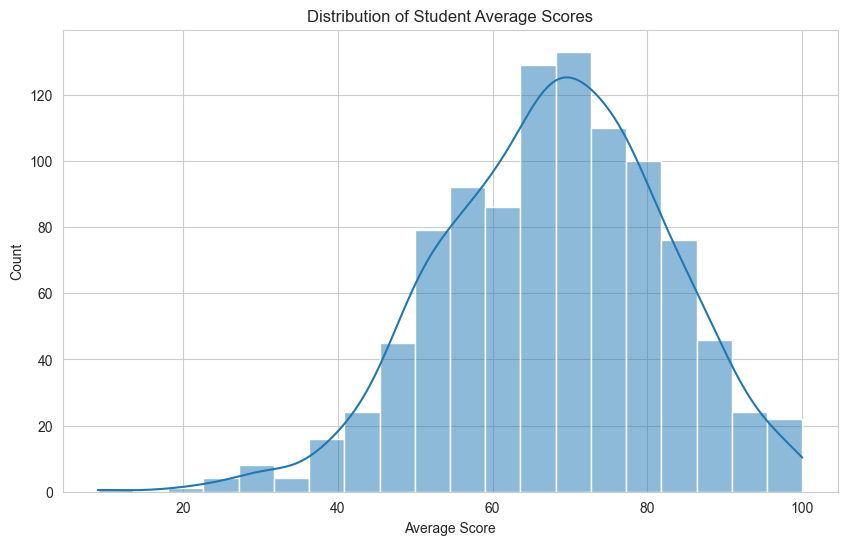

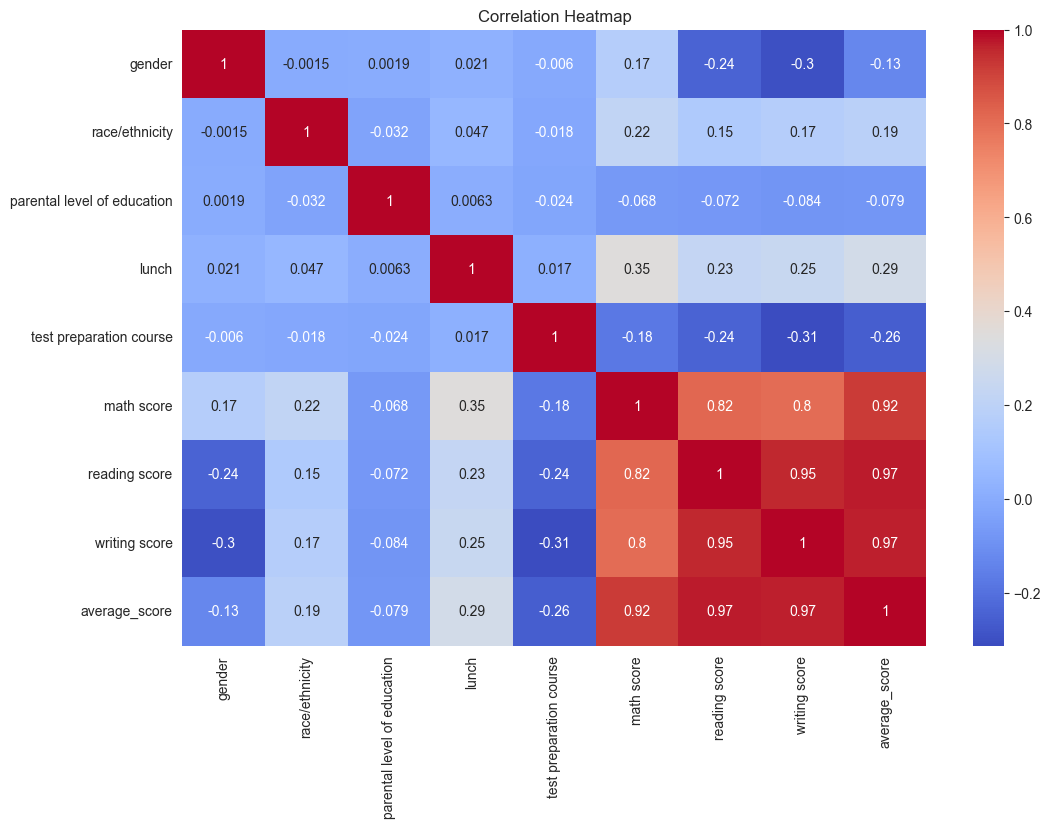

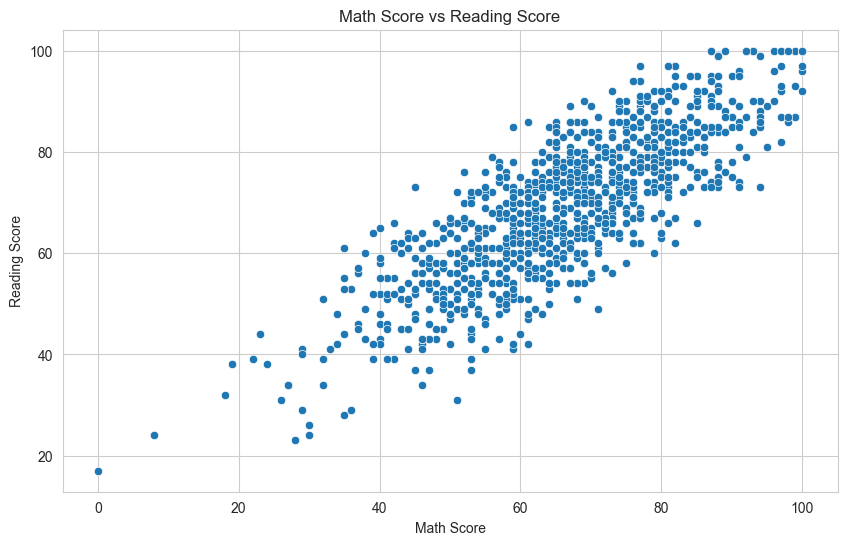

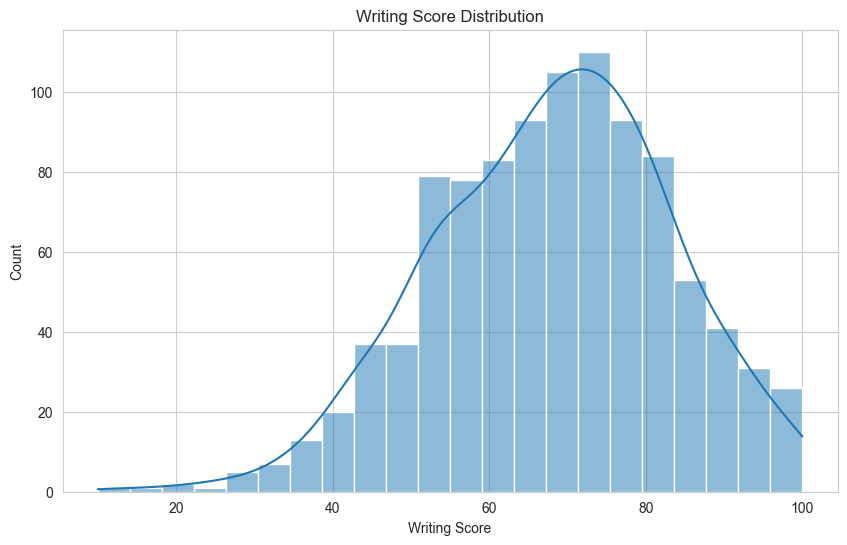

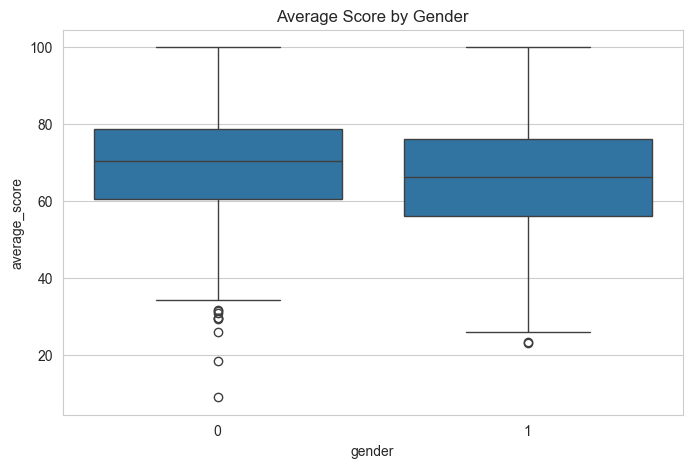

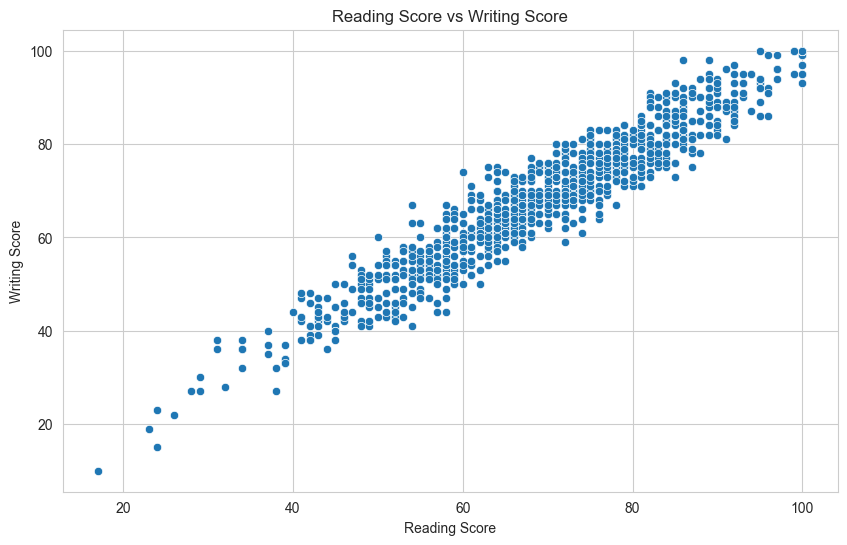


Summary Statistics:

            gender  race/ethnicity  parental level of education        lunch  \
count  1000.000000     1000.000000                  1000.000000  1000.000000   
mean      0.482000        2.174000                     2.486000     0.645000   
std       0.499926        1.157179                     1.829522     0.478753   
min       0.000000        0.000000                     0.000000     0.000000   
25%       0.000000        1.000000                     1.000000     0.000000   
50%       0.000000        2.000000                     2.000000     1.000000   
75%       1.000000        3.000000                     4.000000     1.000000   
max       1.000000        4.000000                     5.000000     1.000000   

       test preparation course  math score  reading score  writing score  \
count              1000.000000  1000.00000    1000.000000    1000.000000   
mean                  0.642000    66.08900      69.169000      68.054000   
std                   0.47965

In [4]:
# =========================================
# Import Libraries
# =========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# Load Cleaned Dataset
# =========================================

file_path = r"C:\Users\arunt\Downloads\cleaned_students.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully!")

# =========================================
# Set Seaborn Style
# =========================================

sns.set_style("whitegrid")

# =========================================
# Display Dataset Info
# =========================================

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

# =========================================
# 1. Distribution of Average Scores
# =========================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df['average_score'],
    bins=20,
    kde=True
)

plt.title("Distribution of Student Average Scores")
plt.xlabel("Average Score")
plt.ylabel("Count")

plt.show()

# =========================================
# 2. Correlation Heatmap
# =========================================

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# =========================================
# 3. Math Score vs Reading Score
# =========================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df['math score'],
    y=df['reading score']
)

plt.title("Math Score vs Reading Score")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")

plt.show()

# =========================================
# 4. Writing Score Distribution
# =========================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df['writing score'],
    kde=True
)

plt.title("Writing Score Distribution")

plt.xlabel("Writing Score")

plt.show()

# =========================================
# 5. Average Score by Gender
# =========================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df['gender'],
    y=df['average_score']
)

plt.title("Average Score by Gender")

plt.show()

# =========================================
# 6. Reading Score vs Writing Score
# =========================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df['reading score'],
    y=df['writing score']
)

plt.title("Reading Score vs Writing Score")

plt.xlabel("Reading Score")
plt.ylabel("Writing Score")

plt.show()

# =========================================
# Summary Statistics
# =========================================

print("\nSummary Statistics:\n")

print(df.describe())

# =========================================
# Insights
# =========================================

print("\nProject Insights:")

print("- Students with high reading scores also perform well in writing.")
print("- Math scores strongly affect average score.")
print("- Some student groups perform better overall.")
print("- Writing and reading scores are highly correlated.")

In [7]:
# =========================================
# STUDENT PERFORMANCE TRACKER
# UPDATED COMPLETE PROJECT CODE
# =========================================

# =========================================
# IMPORT LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# =========================================
# LOAD DATASET
# =========================================

file_path = r"C:\Users\arunt\Downloads\StudentsPerformance.csv"

df = pd.read_csv(file_path)

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

# =========================================
# DISPLAY FIRST ROWS
# =========================================

print("\nFIRST 5 ROWS\n")

print(df.head())

# =========================================
# CHECK MISSING VALUES
# =========================================

print("\nMISSING VALUES\n")

print(df.isnull().sum())

# =========================================
# REMOVE DUPLICATES
# =========================================

before = df.shape[0]

df = df.drop_duplicates()

after = df.shape[0]

print(f"\nREMOVED {before - after} DUPLICATE ROWS")

# =========================================
# HANDLE MISSING VALUES
# =========================================

# Categorical columns
for column in df.select_dtypes(include='object').columns:

    df[column] = df[column].fillna(
        df[column].mode()[0]
    )

# Numerical columns
for column in df.select_dtypes(include=['int64', 'float64']).columns:

    df[column] = df[column].fillna(
        df[column].mean()
    )

print("\nMISSING VALUES HANDLED")

# =========================================
# ENCODE CATEGORICAL COLUMNS
# =========================================

encoder = LabelEncoder()

categorical_columns = df.select_dtypes(
    include='object'
).columns

for column in categorical_columns:

    df[column] = encoder.fit_transform(
        df[column]
    )

print("\nCATEGORICAL COLUMNS ENCODED")

# =========================================
# CREATE TARGET COLUMN
# =========================================

df['average_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
) / 3

print("\nAVERAGE SCORE COLUMN CREATED")

# =========================================
# SAVE CLEANED DATASET
# =========================================

cleaned_path = r"C:\Users\arunt\Downloads\cleaned_students.csv"

df.to_csv(cleaned_path, index=False)

print("\nCLEANED DATASET SAVED")

# =========================================
# FEATURES AND TARGET
# =========================================

X = df.drop(columns=['average_score'])

y = df['average_score']

# =========================================
# TRAIN TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTRAIN TEST SPLIT COMPLETED")

# =========================================
# RANDOM FOREST MODEL
# =========================================

print("\nTRAINING RANDOM FOREST MODEL...")

model = RandomForestRegressor(
    n_estimators=20,
    random_state=42
)

model.fit(X_train, y_train)

print("\nMODEL TRAINING COMPLETED")

# =========================================
# PREDICTIONS
# =========================================

predictions = model.predict(X_test)

# =========================================
# MODEL EVALUATION
# =========================================

rmse = mean_squared_error(
    y_test,
    predictions
) ** 0.5

r2 = r2_score(
    y_test,
    predictions
)

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 2))

# =========================================
# SAVE MODEL
# =========================================

model_path = r"C:\Users\arunt\Downloads\random_forest_model.pkl"

joblib.dump(model, model_path)

print("\nMODEL SAVED SUCCESSFULLY")

# =========================================
# PROFESSIONAL PREDICTION SYSTEM
# =========================================

print("\n" + "=" * 60)
print("STUDENT PERFORMANCE PREDICTION")
print("=" * 60)

# Create DataFrame with feature names
sample_data = pd.DataFrame([{

    'gender': 1,
    'race/ethnicity': 2,
    'parental level of education': 3,
    'lunch': 1,
    'test preparation course': 1,
    'math score': 80,
    'reading score': 85,
    'writing score': 90

}])

# Predict
prediction = model.predict(sample_data)

# =========================================
# DISPLAY PREDICTION
# =========================================

print("\nPREDICTED AVERAGE SCORE")

print(round(prediction[0], 2))

# =========================================
# PROJECT INSIGHTS
# =========================================

print("\n" + "=" * 60)
print("PROJECT INSIGHTS")
print("=" * 60)

print("- Reading and writing scores are highly correlated")
print("- Random Forest provides excellent prediction accuracy")
print("- Student preparation improves performance")
print("- Math score strongly affects final average")

print("\nPROJECT COMPLETED SUCCESSFULLY")

DATASET LOADED SUCCESSFULLY

FIRST 5 ROWS

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

MISSING VALUES

gender                         0
race/ethnicity                 0
parental level of education    0


In [6]:
# =========================================
# Import Libraries
# =========================================

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

# =========================================
# Load Dataset
# =========================================

file_path = r"C:\Users\arunt\Downloads\cleaned_students.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully!")

# =========================================
# Features and Target
# =========================================

# Features (Input Variables)
X = df.drop(columns=['average_score'])

# Target Variable
y = df['average_score']

print("\nFeatures:")
print(X.columns)

print("\nTarget Variable:")
print("average_score")

# =========================================
# Train-Test Split
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)

# =========================================
# Function to Evaluate Models
# =========================================

def evaluate_model(name, y_true, predictions):

    rmse = mean_squared_error(
        y_true,
        predictions
    ) ** 0.5

    r2 = r2_score(
        y_true,
        predictions
    )

    print("\n" + "=" * 50)
    print(f"{name} Performance")
    print("=" * 50)

    print("RMSE:", round(rmse, 2))
    print("R² Score:", round(r2, 2))

# =========================================
# 1. Linear Regression
# =========================================

print("\nTraining Linear Regression...")

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

evaluate_model(
    "Linear Regression",
    y_test,
    linear_predictions
)

# =========================================
# 2. Decision Tree Regressor
# =========================================

print("\nTraining Decision Tree...")

decision_model = DecisionTreeRegressor(
    random_state=42
)

decision_model.fit(
    X_train,
    y_train
)

decision_predictions = decision_model.predict(
    X_test
)

evaluate_model(
    "Decision Tree",
    y_test,
    decision_predictions
)

# =========================================
# 3. Random Forest Regressor
# =========================================

print("\nTraining Random Forest...")

forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_model.fit(
    X_train,
    y_train
)

forest_predictions = forest_model.predict(
    X_test
)

evaluate_model(
    "Random Forest",
    y_test,
    forest_predictions
)

# =========================================
# Save Best Model
# =========================================

model_path = r"C:\Users\arunt\Downloads\random_forest_model.pkl"

joblib.dump(
    forest_model,
    model_path
)

print("\nRandom Forest Model Saved Successfully!")

print("\nSaved Model Location:")
print(model_path)

Dataset Loaded Successfully!

Features:
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

Target Variable:
average_score

Training Data Shape:
(800, 8)

Testing Data Shape:
(200, 8)

Training Linear Regression...

Linear Regression Performance
RMSE: 0.0
R² Score: 1.0

Training Decision Tree...

Decision Tree Performance
RMSE: 1.66
R² Score: 0.99

Training Random Forest...

Random Forest Performance
RMSE: 1.15
R² Score: 0.99

Random Forest Model Saved Successfully!

Saved Model Location:
C:\Users\arunt\Downloads\random_forest_model.pkl


2026-05-22 13:37:28.147 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 13:37:28.149 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 13:37:29.673 
  command:

    streamlit run C:\Users\arunt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-22 13:37:29.676 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 13:37:29.678 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 13:37:29.679 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 1

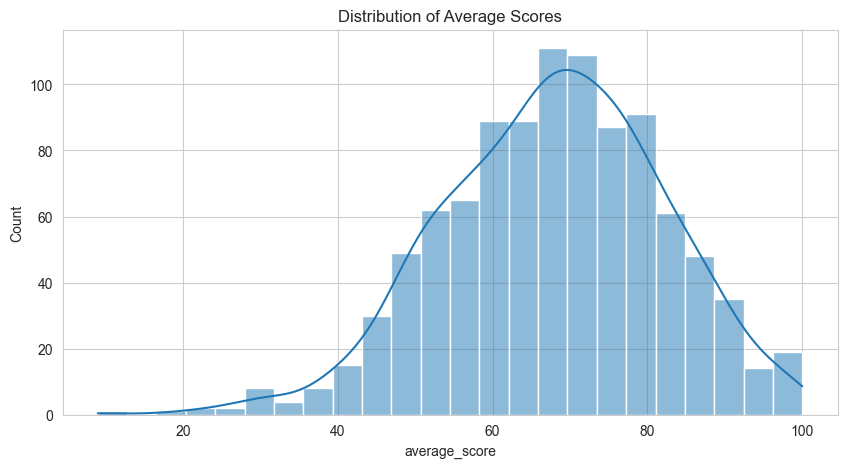

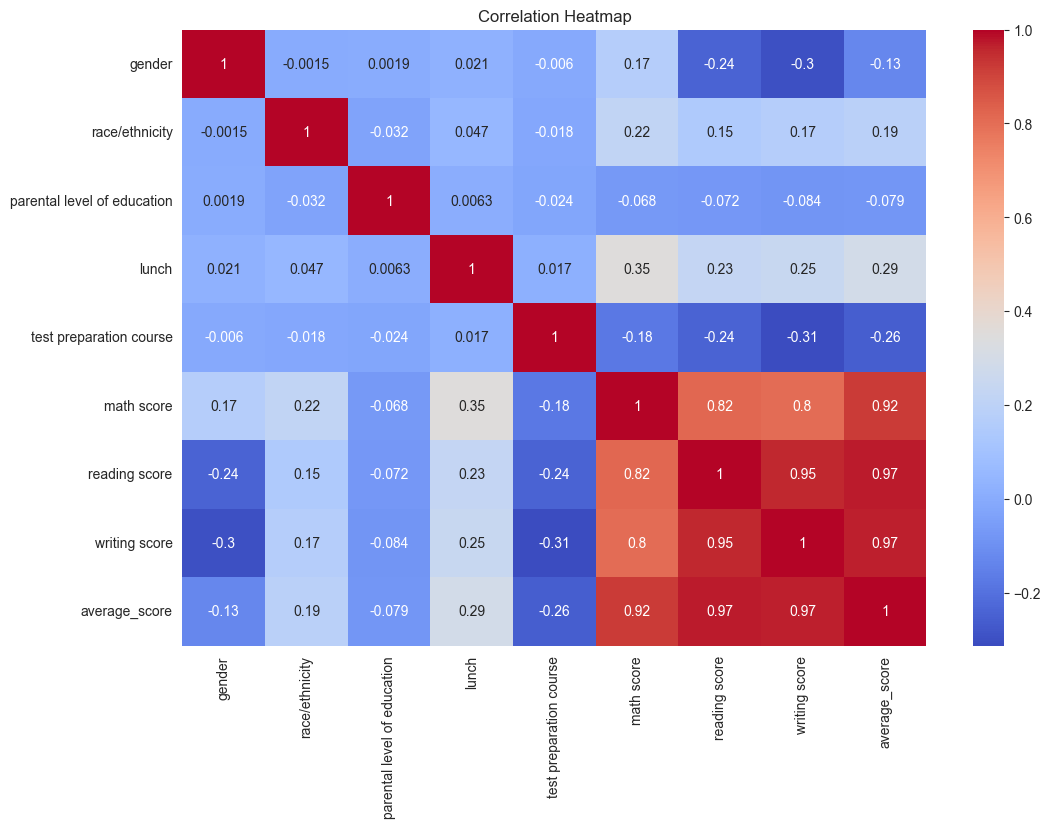

In [8]:
# =========================================
# STUDENT PERFORMANCE TRACKER DASHBOARD
# ERROR-FREE STREAMLIT VERSION
# =========================================

# =========================================
# IMPORT LIBRARIES
# =========================================

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# =========================================
# PAGE CONFIGURATION
# =========================================

st.set_page_config(
    page_title="Student Performance Tracker",
    layout="wide"
)

# =========================================
# TITLE
# =========================================

st.title("Student Performance Tracker")

st.write(
    "Machine Learning Dashboard using Random Forest"
)

# =========================================
# FILE PATHS
# =========================================

DATA_PATH = r"C:\Users\arunt\Downloads\cleaned_students.csv"

MODEL_PATH = r"C:\Users\arunt\Downloads\random_forest_model.pkl"

# =========================================
# CHECK FILES EXIST
# =========================================

if not os.path.exists(DATA_PATH):

    st.error(
        "Cleaned dataset file not found!"
    )

    st.stop()

if not os.path.exists(MODEL_PATH):

    st.error(
        "Model file not found!"
    )

    st.stop()

# =========================================
# LOAD DATASET
# =========================================

try:

    df = pd.read_csv(DATA_PATH)

    st.success("Dataset Loaded Successfully!")

except Exception as e:

    st.error(f"Error Loading Dataset: {e}")

    st.stop()

# =========================================
# LOAD MODEL
# =========================================

try:

    model = joblib.load(MODEL_PATH)

    st.success("Model Loaded Successfully!")

except Exception as e:

    st.error(f"Error Loading Model: {e}")

    st.stop()

# =========================================
# SHOW DATASET
# =========================================

st.header("Dataset Preview")

st.dataframe(df.head())

# =========================================
# DATASET INFORMATION
# =========================================

st.header("Dataset Information")

st.write(df.describe())

# =========================================
# SCORE DISTRIBUTION GRAPH
# =========================================

st.header("Average Score Distribution")

try:

    fig1, ax1 = plt.subplots(figsize=(10, 5))

    sns.histplot(
        df['average_score'],
        kde=True,
        ax=ax1
    )

    ax1.set_title(
        "Distribution of Average Scores"
    )

    st.pyplot(fig1)

except Exception as e:

    st.error(f"Error Creating Histogram: {e}")

# =========================================
# CORRELATION HEATMAP
# =========================================

st.header("Correlation Heatmap")

try:

    fig2, ax2 = plt.subplots(figsize=(12, 8))

    sns.heatmap(
        df.corr(numeric_only=True),
        annot=True,
        cmap='coolwarm',
        ax=ax2
    )

    ax2.set_title("Correlation Heatmap")

    st.pyplot(fig2)

except Exception as e:

    st.error(f"Error Creating Heatmap: {e}")

# =========================================
# PREDICTION SECTION
# =========================================

st.header("Predict Student Performance")

# =========================================
# INPUT FIELDS
# =========================================

col1, col2 = st.columns(2)

with col1:

    gender = st.selectbox(
        "Gender",
        ["Female", "Male"]
    )

    race = st.number_input(
        "Race/Ethnicity Group",
        min_value=0,
        max_value=5,
        value=2
    )

    education = st.number_input(
        "Parent Education Level",
        min_value=0,
        max_value=5,
        value=3
    )

    lunch = st.selectbox(
        "Lunch Type",
        ["Free", "Standard"]
    )

with col2:

    test_prep = st.selectbox(
        "Test Preparation Completed",
        ["No", "Yes"]
    )

    math_score = st.slider(
        "Math Score",
        0,
        100,
        80
    )

    reading_score = st.slider(
        "Reading Score",
        0,
        100,
        85
    )

    writing_score = st.slider(
        "Writing Score",
        0,
        100,
        90
    )

# =========================================
# ENCODE INPUTS
# =========================================

gender_value = 1 if gender == "Male" else 0

lunch_value = 1 if lunch == "Standard" else 0

test_prep_value = 1 if test_prep == "Yes" else 0

# =========================================
# CREATE INPUT DATAFRAME
# =========================================

input_data = pd.DataFrame([{

    'gender': gender_value,

    'race/ethnicity': race,

    'parental level of education': education,

    'lunch': lunch_value,

    'test preparation course': test_prep_value,

    'math score': math_score,

    'reading score': reading_score,

    'writing score': writing_score

}])

# =========================================
# PREDICTION BUTTON
# =========================================

if st.button("Predict Performance"):

    try:

        prediction = model.predict(input_data)

        st.success(
            f"Predicted Average Score: "
            f"{prediction[0]:.2f}"
        )

    except Exception as e:

        st.error(f"Prediction Error: {e}")

# =========================================
# PROJECT INSIGHTS
# =========================================

st.header("Project Insights")

st.write(
    "- Reading and writing scores are highly correlated"
)

st.write(
    "- Random Forest gives high prediction accuracy"
)

st.write(
    "- Student preparation improves performance"
)

st.write(
    "- Math score strongly affects final score"
)

# =========================================
# FOOTER
# =========================================

st.write("---")

st.write(
    "Student Performance Tracker using "
    "Python, Machine Learning, and Streamlit"
)